# 0) 시작하기 전...

필요 library 설치

In [ ]:
!pip install -q -U datasets
!pip install torch transformers pandas

# 1) HuggingFace Transformer

## 다양한 Task 수행해보기

Huggingface 주소: https://huggingface.co/

: Transformer 라이브러리 사용법을 익히고, 여러 NLP task를 알아보자.

Huggingface Transformers Library의 Pipeline 함수란?

> Hugging Face Hub의 모든 models로 다양한 ML 작업에 바로 사용할 수 있는 간단하지만 강력한 추론 API



```
<example>
generator = pipeline(
    task='text-generation',
    model='gpt2',                      
    tokenizer='gpt2',
    device=0 if torch.cuda.is_available() else -1,
    torch_dtype=torch.float16,
)

- feature-extraction
- fill-mask
- named entity recognition
- question-answering
- sentiment-analysis
- summarization
- text-generation
- translation
- zero-shot-classification
```



### Feature Extraction
- 텍스트의 vector representation을 추출하는 task
- 문법 특화 모델인 경우, Input 문장에서 문법적 특징을 더 잘 반영하는 vector를 추출 / 감정 특화 모델인 경우, 감정적 특징을 더 잘 반영하는 vector를 추출.

In [ ]:
from transformers import pipeline

feature_extractor = pipeline(task="feature-extraction")
feature_extractor("Transformers is an awesome library!", return_tensors = "pt") # pytorch tensor 형식으로 반환, "tf" 가능

### Sentimental Analysis
- 문장의 긍정/부정을 판단하는 Task
- 영화 리뷰에 대한 감정 분류 (추후 실습 예정)

In [ ]:
from transformers import pipeline

classifier = pipeline(task="sentiment-analysis")
classifier("I've been waiting for this course my whole life.")

### Text Generation
- Input 문장의 다음에 올 텍스트를 생성하는 task

In [ ]:
from transformers import pipeline

generator = pipeline(task="text-generation")
generator("In this course, we will teach you how to")

### Mask Filling
- 문장 내 <mask> 토큰에 올 텍스트를 예측하는 task
- 오늘 실습할 BERT가 동일한 방법으로 학습을 진행하였음

In [ ]:
from transformers import pipeline

unmasker = pipeline(task="fill-mask")
unmasker("This course will teach you all about <mask> models.", top_k=2)

### Named Entity Recognition (NER)
- 개체명을 인식(=어떤 범주에 포함되는지)하는 task

In [ ]:
from transformers import pipeline

ner = pipeline(task="ner", aggregation_strategy="simple") # 기본, "none"/"first"/"average"/"max"
ner("My name is Hyejun and I work at Hugging Face in Brooklyn.")

### Question Answering
- Context를 주고, 질문을 했을 때 적절한 대답을 생성하는 task

In [ ]:
from transformers import pipeline

question_answerer = pipeline(task="question-answering")
question_answerer(
    question="Where do I work?",
    context="My name is Hyejun and I work at Hugging Face in Brooklyn",
)

### Zero-shot classification
- 학습 중에 본 적이 없는 클래스에 대해 분류를 수행하는 task

In [ ]:
from transformers import pipeline

classifier = pipeline(task="zero-shot-classification")
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "politics", "business"],
)

## Neural Machine Translation

1. 번역 task를 수행하기 위해 학습된 모델 불러오기
2.  데이터 전처리 - 모델 통과 - 데이터 후처리 과정 수행 (pipeline의 역할)

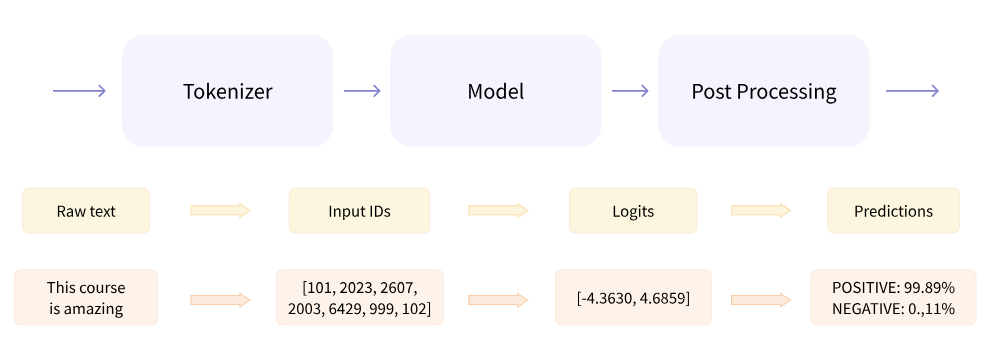

Q. **어떤 모델을 사용?**  
Helsinki-NLP team에서 만든 transformers 기반 **encoder-decoder** model인 **Marian NMT**를 사용.  
모델 주소: https://www.huggingface.co/Helsinki-NLP/opus-mt-ko-en

Q. **Tokenize?**  
긴 문장을 **Tokens(단어 또는 의미 있는 단위)**로 나누고,
컴퓨터가 이해할 수 있도록 숫자로 바꾸는 과정

Q. **Pretrained Tokenizer?**  
언어모델과 함께 훈련된 tokenizer.  
model이 기대하는 입력 형식으로 tokenizing을 수행함.   
예를 들어, 단어를 어떤 subword로 나눌지 (vocabulary를 어떻게 구성할지), 나눠진 token에 어떤 index를 매길지, 어떤 special token (ex. EOS, SOS ...) 등을 어떤 index를 매길지 등등


In [ ]:
import torch
from transformers import MarianMTModel, MarianTokenizer

# Pretrained 모델과 토크나이저 로드 (한국어 -> 영어)
model_name = 'Helsinki-NLP/opus-mt-ko-en'

# pretrained tokenizer와 model을 불러오기
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

# 입력 문장
input_text = "안녕하세요, 자연어 처리의 Transformer 모델을 실습해보겠습니다."

# tokenization -> model 통과 -> 후처리 (decode)
input_ids = tokenizer(input_text, return_tensors="pt").input_ids # 데이터 전처리 (text -> token)
print(input_ids)

outputs = model.generate(input_ids) # 모델 통과 (generation (enc -> dec))

translated_text = tokenizer.decode(outputs[0], skip_special_tokens=True) # 데이터 후처리 (token -> text)
# skip special tokens? EOS, SOS 토큰 등 speical한 token은 사용자에게 보이지 않겠다는 뜻!

print("Input:", input_text)
print("Translated:", translated_text)

## Document Summarization

Q. **어떤 모델을 사용?**  
--> T5 model을 한국어 요약문 및 레포트 생성 데이터로 fine-tuning한 모델 (enc - dec)

Q. **AutoTokenizer란?**  
--> Hugging Face Transformers library에서 제공하는 자동 tokenizer loader  
--> **모델에 맞는 Tokenizer를 자동으로 불러옴**

Q. **AutoModelForSeq2SeqLM란?**  
--> Encoder-Decoder 구조의 model을 자동으로 불러오는 loader  
ex. T5, BART, MarianMT 등등

모델 주소: https://huggingface.co/lcw99/t5-base-korean-text-summary

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "EbanLee/kobart-summary-v3"
tokenizer = ### Tokenizer 선언 (AutoTokenizer 사용) ###
model = ### model 선언 (AutoModelForSeq2SeqLM 사용) ###

text = """
삼성전자가 16일부터 이틀간 진행한 2026년형 TV와 오디오 신제품 체험행사 '삼성 AI TV 위크'가 마무리됐다고 19일 밝혔다.
일반 고객과 B2B 거래선 등 현장을 찾은 방문객들은 신제품 체험존에서 '마이크로 RGB', 'OLED' 등 프리미엄 TV 라인업부터 이동형 스크린 '무빙스타일', 라이프스타일 TV '더 프레임', 와이파이 스피커 '뮤직 스튜디오 5·7' 등 소비자 라이프스타일에 맞춰 다양하게 활용 가능한 삼성 TV 및 사운드 디바이스 신제품 라인업을 만나볼 수 있었다.
"""

inputs = ["summarize: " + text]

#### tokenizer() - Input data 전처리 ####
1.
#### model의 generate() - Input data 모델 통과 ####
#### argument로 min_length=10, max_length=100 추가 ####
2.
#### tokenizer.decode() - 최종 output 생성 ####
3.

print(summarized_text)

# 2) BERT

## BERT Basic

### BERT Tokenizer
- Tokenize - 입력된 텍스트를 모델에서 처리할 수 있는 데이터로 변환하는 것
- BERT는 WordPiece tokenizing 방식을 사용  
ex1) "transformers" → ["transform", "##ers"]  
ex2) "unbelievable" → ["un", "##bel", "##iev", "##able"]

In [ ]:
import pandas as pd
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased") # Bert-base의 토크나이저

In [ ]:
result = tokenizer.tokenize('Here is the sentence I want embeddings for.')
print(result)

In [ ]:
print(tokenizer.vocab['here'])

In [ ]:
# subword로 쪼개졌기 때문에 vocab에 없음. subword 별로 확인해보자!
print(tokenizer.vocab['embeddings'])

In [ ]:
print(tokenizer.vocab['em'])

In [ ]:
print(tokenizer.vocab['##bed'])

In [ ]:
print(tokenizer.vocab['##ding'])

In [ ]:
print(tokenizer.vocab['##s'])

### Masked Language Modeling

In [ ]:
from transformers import BertForMaskedLM
from transformers import AutoTokenizer

In [ ]:
model = BertForMaskedLM.from_pretrained('bert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [ ]:
inputs = tokenizer('Samsung is [MASK] company.', return_tensors='pt')
outputs = model(**inputs)
# outputs = model(input_ids = inputs.input_ids, attention_mask = inputs.attention_mask)
# 와 동일
print(outputs)

#### 정수 인코딩 결과
[PAD] - 0, [UNK] - 100, [CLS] - 101, [SEP] - 102, [MASK] - 103

In [ ]:
print(inputs['input_ids']) # 정수 인코딩된 결과
print(tokenizer.decode(inputs['input_ids'][0])) # 다시 decoding 해보면?

#### Segment 인코딩 결과
- 입력이 두 문장이라면 두 번째 문장은 1의 값을 가집니다.

In [ ]:
print(inputs['token_type_ids'])

In [ ]:
inputs = tokenizer('Samsung is [MASK] company.', 'I work at Samsung.', padding=True, return_tensors='pt')
print(inputs['token_type_ids'])

#### Attention mask 결과
- \<PAD> 토큰이 아니라면 모두 1의 값을 가집니다.
- 즉, Attention mask란 학습되지 않는 \<PAD> 토큰을 구분하는 용도

In [ ]:
print(inputs['attention_mask'])

In [ ]:
inputs = tokenizer(['Samsung is [MASK] company.', 'I work at Samsung.'], padding=True, return_tensors='pt')
print(inputs['input_ids'])
print(inputs['attention_mask'])

#### [MASK] 토큰 예측  

In [ ]:
from transformers import FillMaskPipeline
fill_mask = FillMaskPipeline(model=model, tokenizer=tokenizer)
# 문장의 [MASK] 위치에 올 가능한 단어를 예측해주는 pipeline

In [ ]:
fill_mask('Samsung is a [MASK] company in korea.')

- 정리 : BERT는 [MASK] Token을 예측하는 방식으로 학습되었다.

### Next Sentence Prediction

In [ ]:
from transformers import BertForNextSentencePrediction
from transformers import AutoTokenizer
import torch
import torch.nn.functional as F

In [ ]:
model = BertForNextSentencePrediction.from_pretrained('bert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

In [ ]:
prompt = "I work at Samsung"
next_sentence = "Samsung is a good company in korea"

In [ ]:
encoding = tokenizer(prompt, next_sentence, return_tensors='pt')

#### 정수 인코딩 결과
- [SEP] 102 토큰으로 문장을 구분

In [ ]:
print(encoding['input_ids'])

In [ ]:
print(tokenizer.decode(encoding['input_ids'][0]))

#### Segment 인코딩 결과
- 0과 1을 통해, 문장 간의 segment를 구분해 주었다.


In [ ]:
print(encoding['token_type_ids'])

#### Next Sentence Prediction 실습

- BERT가 NextSentencePrediction 학습을 진행할 때, 두 문장이 이어지는 문장인지를 두고 IsNext와 IsNotNext 2개의 경우로 구분
- IsNext인 경우는 두 sentence pair의 label을 0으로 학습
- IsNotNext의 경우는 두 sentence pair의 label을 1로 학습

--> 즉, 0의 확률이 클수록 이어지는 문장이라고 판단내린 것

In [ ]:
# 모델 출력 (logits) 얻기
logits = model(encoding['input_ids'], token_type_ids=encoding['token_type_ids']).logits

# 소프트맥스 확률 계산
probs = F.softmax(logits, dim=-1)

# 출력
labels = ['IsNext', 'NotNext']
for label, prob in zip(labels, probs[0]):
    percent = prob.item() * 100
    print(f"{label:8s}: {percent:.1f}%")

- 만약 연관 없는 두 문장을 입력으로 준다면?

In [ ]:
prompt = "Samsung is a good company in korea"
next_sentence = "I'm a student"

encoding = tokenizer(prompt, next_sentence, return_tensors='pt')
logits = model(encoding['input_ids'], token_type_ids=encoding['token_type_ids']).logits
probs = F.softmax(logits, dim=-1)

labels = ['IsNext', 'NotNext']
for label, prob in zip(labels, probs[0]):
    percent = prob.item() * 100
    print(f"{label:8s}: {percent:.1f}%")

## BERT 이용 영화 리뷰 감성분석
- BERT를 실제 데이터를 통해 fine-tuning 해보기  
- fine-tuning 된 모델을 test 해보기

cf) Pandas & Numpy?
- Pandas: Table 형식의 데이터를 쉽게 다룰 수 있게 해주는 Python Library
- Numpy: 수치 계산을 빠르게 하기 위한 Python Library

In [ ]:
import torch

from transformers import BertTokenizer, BertForSequenceClassification, BertConfig
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
import numpy as np

### Naver 영화리뷰 감정분석 데이터 다운로드

In [ ]:
!git clone https://github.com/e9t/nsmc.git

### Pandas로 training data와 test data 로드

In [ ]:
train = pd.read_csv("nsmc/ratings_train.txt", sep='\t')
test = pd.read_csv("nsmc/ratings_test.txt", sep='\t')

train = train[:1500]
test = test[:500]
train.head(15)

### document와 label 분리 (데이터 전처리)

In [ ]:
train_document = [str(sentence) for sentence in train['document']]
train_label = [label for label in train['label']]
test_document = [str(sentence) for sentence in test['document']]
test_label = [label for label in test['label']]

print(train_document[:3])
print(train_label[:3])

### BERT Tokenizer를 사용하여 데이터 전처리

In [ ]:
# BERT의 토크나이저로 문장을 토큰으로 분리
tokenizer = BertTokenizer.from_pretrained('distilbert/distilbert-base-multilingual-cased', do_lower_case=False)
train_tokens = tokenizer(train_document, padding=True, truncation=True, return_tensors="pt")
test_tokens = tokenizer(test_document, padding=True, truncation=True, return_tensors="pt")

# print(sentences[0])
print(train_tokens['input_ids'][0])
print(tokenizer.decode(train_tokens['input_ids'][0]))

### Transformers의 Dataset, DataLoader 사용

In [ ]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_tokens, train_label)
test_dataset = ReviewDataset(test_tokens, test_label)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Model import (distilbert)

In [ ]:
model = BertForSequenceClassification.from_pretrained('distilbert/distilbert-base-multilingual-cased', num_labels=2)

### 학습 전 성능 체크

In [ ]:
correct_predictions = 0
total_predictions = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        #input_ids:     [101, 146, 1567, 1128, 0, 0]

        # huggingface tokenizer 사용 시, attention_mask 자동 생성
        attention_mask = batch['attention_mask'].to(device)
        #attention_mask:[  1,   1,    1,    1, 0, 0]

        # 예측해야 하는 정답 labels
        labels = batch['labels'].to(device)

        model = model.to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        _, predicted_labels = torch.max(outputs.logits, dim=1)

        correct_predictions += torch.sum(predicted_labels == labels).item()
        total_predictions += labels.size(0)

accuracy = correct_predictions / total_predictions
print(f"Test accuracy before fine-tuning: {accuracy:.4f}")

In [ ]:
from transformers import pipeline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
nsmc_classifier = pipeline('sentiment-analysis',
                           model=model.cpu(), tokenizer=tokenizer, framework='pt')
id2label = {"LABEL_0": "negative", "LABEL_1": "positive"}

reviews= [
          "생각한 것보다는 영화가 재미없었어",
          "역시 재밌네ㅋㅋ 최고",
          "재밌긴한데, 재미없는 것 같기도 해"
]

results = nsmc_classifier(reviews)
for idx, result in enumerate(results):
    print(reviews[idx])
    for k, v in result.items():
        print(f" >> {k} : {id2label[v] if k == 'label' else v}")
    print()

# nsmc_classifier.save_pretrained('./pipeline')

### Fine-tuning 진행

In [ ]:
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_epochs = 3
learning_rate = 2e-5
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()
model.to(device) # GPU 사용이 가능한 경우

model.train()
for epoch in range(num_epochs):
    total_loss = 0

    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # optimizer 초기화
        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        # back propagation
        loss.backward()

        # model parameter update
        optimizer.step()

    average_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Average Loss: {average_loss:.4f}")

### Fine-tuning 후 Test

In [ ]:
model.eval()
correct_predictions = 0
total_predictions = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        _, predicted_labels = torch.max(outputs.logits, dim=1)

        correct_predictions += torch.sum(predicted_labels == labels).item()
        total_predictions += labels.size(0)

accuracy = correct_predictions / total_predictions
print(f"Test accuracy after fine-tuning: {accuracy:.4f}")

### Fine-tuning 모델 성능 확인

In [ ]:
from transformers import pipeline

nsmc_classifier = pipeline('sentiment-analysis',
                           model=model.cpu(), tokenizer=tokenizer, framework='pt')

results = nsmc_classifier(reviews)
for idx, result in enumerate(results):
    print(reviews[idx])
    for k, v in result.items():
        print(f" >> {k} : {id2label[v] if k == 'label' else v}")
    print()

# nsmc_classifier.save_pretrained('./pipeline')

### Fine-tuned model 사용하여 Sentiment Analysis pipline 구축
- sangrimlee/bert-base-multilingual-cased-nsmc
- 위 모델 명 사용하여 pipeline 구축
- 테스트 했던 리뷰 문장 테스트 해보기 (Inference)

모델 주소: https://www.huggingface.co/sangrimlee/bert-base-multilingual-cased-nsmc

In [ ]:
from transformers import pipeline

### pipeline 구축 ###

### Inference ###


## 한국어 감정 분석 실습 (다중 분류)

In [ ]:
import torch

from transformers import BertTokenizer
from transformers import BertForSequenceClassification, BertConfig
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np

### 한국어 감정 분석 데이터 전처리

In [ ]:
!git clone https://github.com/dongwxxkchoi/day2.git

In [ ]:
data = pd.read_excel('./day2/data.xlsx') ## pd.read_json 이용

data=data.iloc[:,:2]
data.head(10)

- 직접 tokenize 함수를 사용해서 데이터 전처리 해보기

In [ ]:
data.loc[(data['Emotion'] == "공포"), 'Emotion'] = 0  #공포 => 0
data.loc[(data['Emotion'] == "놀람"), 'Emotion'] = 1  #놀람 => 1
data.loc[(data['Emotion'] == "분노"), 'Emotion'] = 2  #분노 => 2
data.loc[(data['Emotion'] == "슬픔"), 'Emotion'] = 3  #슬픔 => 3
data.loc[(data['Emotion'] == "중립"), 'Emotion'] = 4  #중립 => 4
data.loc[(data['Emotion'] == "행복"), 'Emotion'] = 5  #행복 => 5
data.loc[(data['Emotion'] == "혐오"), 'Emotion'] = 6  #혐오 => 6

data_sentence = ### 직접 작성 ###
data_label = ### 직접 작성 ###

x_train, x_test, y_train, y_test = train_test_split(data_sentence, data_label, test_size=0.2, shuffle=True)
print(x_train[:10])
print(y_train[:10])

x_train = x_train[:1500]
y_train = y_train[:1500]
x_test = x_test[:500]
y_test = y_test[:500]

모델 주소: https://huggingface.co/klue/bert-base

In [ ]:
# BERT('klue/bert-base')의 토크나이저로 문장을 토큰으로 분리
tokenizer = ### 직접 작성 ###
train_tokens = ### 직접 작성 ###
test_tokens = ### 직접 작성 ###

# print(sentences[0])
print(train_tokens['input_ids'][0])
print(tokenizer.decode(train_tokens['input_ids'][0]))

In [ ]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_tokens, y_train)
test_dataset = ReviewDataset(test_tokens, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

- 'klue/bert-base' 모델 불러오기

In [ ]:
model = ### 직접 작성 ###

In [ ]:
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_epochs = 3
learning_rate = 2e-5
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()
model.to(device) # GPU 사용이 가능한 경우

model.train()

for epoch in range(num_epochs):
    total_loss = 0

    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    average_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Average Loss: {average_loss:.4f}")

In [ ]:
model.eval()
correct_predictions = 0
total_predictions = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        _, predicted_labels = torch.max(outputs.logits, dim=1)

        correct_predictions += torch.sum(predicted_labels == labels).item()
        total_predictions += labels.size(0)

accuracy = correct_predictions / total_predictions
print(f"Test Accuracy: {accuracy:.4f}")

pipeline 활용해보기

In [ ]:
from transformers import pipeline

sentiment_classifier = ### 직접 작성 ###

id2label = {
    "LABEL_0": "공포",
    "LABEL_1": "놀람",
    "LABEL_2": "분노",
    "LABEL_3": "슬픔",
    "LABEL_4": "중립",
    "LABEL_5": "행복",
    "LABEL_6": "혐오"
}

sentence = ### 직접 작성 ###

result = ### 직접 작성 ###
print(result)

print(f"{id2label[result[0]['label']]}")

# sentiment_classifier.save_pretrained('./pipeline')

## BERT 기반 한국어 감정 분류모델 (pipeline 이용)
- hun3359/klue-bert-base-sentiment
- 위 모델 명 사용하여 pipeline 구축 (단 2줄)
- Inference 해보기

모델 주소: https://huggingface.co/hun3359/klue-bert-base-sentiment

In [ ]:
from transformers import pipeline

### pipeline 구축 ###

### Inference ###


# 3) GPT-2

## 텍스트 생성해보기

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, pipeline

In [ ]:
# 토크나이저 및 모델 초기화
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

# 텍스트 생성 파이프라인 설정
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)
# generator = pipeline("text-generation", model="gpt2") # 이것도 가능. tokenizer 자동 호출

# 텍스트 생성 예제
prompt = "Once upon a time in a faraway land"
generated_text = generator(prompt, max_length=100, num_return_sequences=1)

print("\n\nGenerated Text:")
print(generated_text[0]['generated_text'])

## GPT-2로 챗봇 만들어보기

In [ ]:
from transformers import pipeline

In [ ]:
# 토크나이저 및 모델 초기화
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

# 텍스트 생성 파이프라인 설정
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    # pad_token_id=tokenizer.eos_token_id,
    # gpt-2 같은 경우는, tokenizer가 padding token 정의 x.
    # 문서의 sentences를 이어 붙여서, padding 없이 eos_token 만으로 구분해 같은 크기로 나눴기 때문.
    # 하지만, batch 단위 생성 시 padding 필요하므로 eos token으로 별도로 지정해주기
)

def chat_with_gpt2(user_input):
    response = generator(user_input, max_new_tokens=100, num_return_sequences=1)
    full_text = response[0]['generated_text']
    generated_part = full_text[len(user_input):].strip()
    return generated_part

# 예시 대화
conversation = True
print("Let's talk to GPT-2! If do you want to stop to talk, input the word, 'Stop'")

while conversation == True:
  user_input = input('You: ')
  if user_input == 'Stop' or user_input == 'stop':
    conversation = False
  else:
    print('GPT-2: ', chat_with_gpt2(user_input))

* 좀더 chatbot과 유사하게 만들어보기
* 현재 대화 데이터를 chat-history에 유지하는 챗봇

In [ ]:
# example
chat_history = [
    "User: Hello!",
    "Bot: Hi there! How can I assist you today?",
    "User: What is the weather like in Seoul?",
    "Bot: I’m not connected to real-time data, but typically in June, Seoul is warm and humid with occasional rain.",
    "User: Thanks! Can you tell me a joke?",
    "Bot: Sure! Why don’t scientists trust atoms? Because they make up everything.",
    "User: Haha! What's the capital of France?",
    "Bot: The capital of France is Paris.",
    "User: How do I cook pasta?",
    "Bot: First, bring a pot of water to a boil, add salt, then add your pasta. Cook for 8–10 minutes, stirring occasionally, then drain and serve."
]

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, pipeline

# 모델 및 토크나이저 초기화
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

# pipeline 생성
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

# 대화 이력 초기화
chat_history = []

def chat_with_gpt2(user_input):
    global chat_history

    # 1. 사용자 입력 추가
    chat_history.append(f"User: {user_input}")

    # 2. 전체 히스토리를 하나의 prompt로 구성
    prompt = "\n".join(chat_history) + "\nBot:"

    # 3. 모델을 사용하여 응답 생성
    response = generator(
        prompt,
        max_new_tokens=50,
        num_return_sequences=1,
        pad_token_id=tokenizer.eos_token_id,
    )

    # 4. 응답 텍스트 파싱
    generated_text = response[0]['generated_text']
    bot_reply = generated_text[len(prompt):].strip().split("\n")[0]  # 첫 줄만 추출

    # 5. 봇 응답 저장
    chat_history.append(f"Bot: {bot_reply}")

    return bot_reply, chat_history

# 예시 대화 루프
print("Let's talk to GPT-2! If you want to stop, type 'Stop'")

while True:
    user_input = input("User: ")
    if user_input.lower() == "stop":
        break
    bot_reply, _ = chat_with_gpt2(user_input)
    print(f"Bot: {bot_reply}")

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, pipeline

# 모델 및 토크나이저 초기화
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

# pipeline 생성
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

# 대화 이력 초기화
chat_history = []

def chat_with_gpt2(user_input):
    global chat_history

    # 1. 사용자 입력 추가
    chat_history.append(f"User: {user_input}")

    # 2. 전체 히스토리를 하나의 prompt로 구성
    prompt = "\n".join(chat_history) + "\nBot:"

    # 3. 모델을 사용하여 응답 생성
    response = generator(
        prompt,
        max_new_tokens=50,
        num_return_sequences=1,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=True,           # 추가> 다양성 확보!
        top_k=50,                 # 추가> 상위 50개 후보 중 샘플링!
        temperature=0.8           # 추가> 창의성 조절!
        # what's these???????
    )

    # 4. 응답 텍스트 파싱
    generated_text = response[0]['generated_text']
    bot_reply = generated_text[len(prompt):].strip().split("\n")[0]  # 첫 줄만 추출

    # 5. 봇 응답 저장
    chat_history.append(f"Bot: {bot_reply}")

    return bot_reply, chat_history

# 예시 대화 루프
print("Let's talk to GPT-2! If you want to stop, type 'Stop'")

while True:
    user_input = input("User: ")
    if user_input.lower() == "stop":
        break
    bot_reply, _ = chat_with_gpt2(user_input)
    print(f"Bot: {bot_reply}")

## Decoding Strategy 점검

### a) 결정적 / Search Based

In [ ]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2", pad_token_id=tokenizer.eos_token_id)

In [ ]:
prompt = "I enjoy walking with my cute dog"

input_ids = tokenizer.encode(prompt, return_tensors='pt')

greedy_output = model.generate(input_ids,
                               max_length=50)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(greedy_output[0], skip_special_tokens=True))

In [ ]:
beam_output = model.generate(
    input_ids,
    max_length=50,
    num_beams=5, # num_beams = 5로 설정해 5개의 후보를 유지하도록 함
    early_stopping=True # 만약 후보 중 하나가 생성이 끝났고, 가장 높은 확률을 갖는다면 그걸 선택하기
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(beam_output[0], skip_special_tokens=True))

In [ ]:
beam_output = model.generate(
    input_ids,
    max_length=50,
    num_beams=5,
    no_repeat_ngram_size=2, # 반복 방지 parameter
    early_stopping=True
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(beam_output[0], skip_special_tokens=True))

In [ ]:
beam_output = model.generate(
    input_ids,
    max_length=50,
    num_beams=5,
    repetition_penalty=1.5, # 반복 방지 parameter
    early_stopping=True
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(beam_output[0], skip_special_tokens=True))

*   한국어로 해보기




In [ ]:
from transformers import GPT2LMHeadModel
model = GPT2LMHeadModel.from_pretrained(
    "skt/kogpt2-base-v2",
)
model.eval()

In [ ]:
from transformers import PreTrainedTokenizerFast
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    eos_token="</s>",
)

In [ ]:
input_ids = tokenizer.encode("안녕하세요", return_tensors="pt")

In [ ]:
import torch

# greedy search
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=False,
        min_length=10,
        max_length=50,
    )

print('Greedy search: ', tokenizer.decode([el.item() for el in generated_ids[0]]))

In [ ]:
# Beam search
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=False,
        min_length=10,
        max_length=50,
        num_beams=3,
    )
    print(tokenizer.decode([el.item() for el in generated_ids[0]]))

- N-gram penalty를 적용해 본다면?

In [ ]:
# Beam search
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=False,
        min_length=10,
        max_length=50,
        num_beams=3,
        no_repeat_ngram_size=2,
    )
    print(tokenizer.decode([el.item() for el in generated_ids[0]]))

- Token-based penalty를 적용해 본다면?

In [ ]:
# Beam search
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=False,
        min_length=10,
        max_length=50,
        num_beams=3,
        repetition_penalty=2.0
    )
    print(tokenizer.decode([el.item() for el in generated_ids[0]]))

### b) 확률적 / Sampling Based

In [ ]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2", pad_token_id=tokenizer.eos_token_id)

In [ ]:
prompt = "Once upon a time"

input_ids = tokenizer.encode(prompt, return_tensors='pt')
greedy_output = model.generate(input_ids, max_length=50)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(greedy_output[0], skip_special_tokens=True))

In [ ]:
output_1 = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    temperature=0.5
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(output_1[0], skip_special_tokens=True))

In [ ]:
output_2 = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    temperature=1.5
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(output_2[0], skip_special_tokens=True))

In [ ]:
output_3 = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    top_k=50
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(output_3[0], skip_special_tokens=True))

In [ ]:
output_4 = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    top_p=0.9
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(output_4[0], skip_special_tokens=True))

In [ ]:
output_5 = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    top_k=40,
    top_p=0.9,
    temperature=1.0
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(output_5[0], skip_special_tokens=True))

### 각 상황에 알맞은 Decoding Strategy 찾아보기 (실습)
- 지금까지 배운 다양한 전략들을 사용해, 각 경우에 **가장 잘 맞는 strategy를 결정해보기**

#### cf) parameter 정리

1. 출력 길이 제어
- max_length: 생성될 시퀀스의 최대 길이
- min_length: 최소 생성 길이. 이보다 짧으면 eos_token을 무시함
- early_stopping: True이면 eos_token이 생성되면 바로 중단

2. Search 기반 전략
- num_beams: Beam search를 위한 beam 개수 설정
- num_return_sequences: 몇 개의 결과를 출력할지 (beam search 시 여러 개 받을 수 있음)
- length_penalty: 짧은 문장을 불이익, 긴 문장을 선호하는 정도 조절 (1.0: 기본)
- early_stopping: True이면 beam search 중 eos_token 등장 시 바로 종료

3. 반복 제어 전략
- no_repeat_ngram_size: 같은 n-gram 반복 금지
- repetition_penalty: 반복되는 토큰에 페널티 부여

4. Sampling 기반 전략
- do_sample: Sampling 전략 사용 여부 (True 시 아래 옵션들과 함께 사용됨)
- temperature: 확률 분포 조절 (높을 수록 다양성 증가)
- top_k: 상위 k개의 token만 sampling 후보로 사용
- top_p: 누적 확률 p 까지의 토큰들만 sampling 후보로 사용




모델 주소: https://huggingface.co/skt/kogpt2-base-v2

In [ ]:
import torch
from transformers import GPT2LMHeadModel
from transformers import PreTrainedTokenizerFast

model = GPT2LMHeadModel.from_pretrained(
    "skt/kogpt2-base-v2",
)

tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    bos_token='</s>', eos_token='</s>', unk_token='<unk>', pad_token='<pad>', mask_token='<mask>'
)

model.eval()

- 창의적인 대답이 필요한 경우?
- 안정적인 대답이 필요한 경우?
- 반복 제어가 필요한 경우?  
각 경우로 분류해보고 알맞은 decoding strategy를 사용해보자

In [ ]:
prompt = "미래에는 인간과 인공지능이 함께"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

In [ ]:
prompt = "삶의 의미는 무엇일까?"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

In [ ]:
prompt = "지구는 태양으로부터"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

In [ ]:
prompt = "광합성은 식물이 빛을 이용하여"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

In [ ]:
prompt = "경제 인플레이션이 발생하는 이유는"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

In [ ]:
prompt = "기술은 빠르게 변화하고 있다. 기술은 우리의 일상생활에 영향을 미친다. 기술은 계속해서"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

# 각자의 decoding strategy 체험해보기
with torch.no_grad():
    generated_ids = model.generate(
        input_ids,
        do_sample=True,
        temperature=1.0,
        min_length=10,
        max_length=50,
    )

print(tokenizer.decode([el.item() for el in generated_ids[0]]))

# 4) BERT vs GPT-2

## Sentimental Analysis

- Sentimental Analysis dataset으로 BERT test
- SST-2 (Stanford Sentiment Treebank 2)는 Stanford NLP Group에서 만든 대표적인 감성 분석(Sentiment Analysis) 데이터셋

In [ ]:
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import TensorDataset, DataLoader

# SST-2 데이터셋 로드
dataset = load_dataset("glue", "sst2")

# 데이터셋의 일부분만 사용 (속도 향상을 위해)
small_test_dataset = dataset['validation'].shuffle(seed=42).select(range(500))

In [ ]:
class SST2Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
from tqdm import tqdm

# BERT 토크나이저 및 모델 로드
bert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")
bert_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")

# 모델 평가 모드로 설정
bert_model.eval()

In [ ]:
# 데이터 전처리
texts = list(small_test_dataset['sentence'])
labels = list(small_test_dataset['label'])

encodings = bert_tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

# sst 데이터셋 인스턴스 생성
test_dataset_bert = SST2Dataset(encodings, labels)

# DataLoader 설정
test_loader_bert = DataLoader(test_dataset_bert, batch_size=32, shuffle=False)

In [ ]:
# 예측 수행
correct = 0
total = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    for _, batch in tqdm(enumerate(test_loader_bert)):
        inputs = {key: val for key, val in batch.items() if key != 'labels'}
        labels = batch['labels']
        outputs = bert_model(**inputs)
        predictions = torch.argmax(outputs.logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

bert_accuracy = correct / total
print(f"BERT Accuracy: {bert_accuracy:.2f}")

In [ ]:
sample_text = "This movie was surprisingly good."

inputs = bert_tokenizer(sample_text, return_tensors="pt", truncation=True, padding=True)

with torch.no_grad():
    outputs = bert_model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=-1).item()
    probs = torch.softmax(outputs.logits, dim=-1)

label_map = {0: "negative", 1: "positive"}

print("Text:", sample_text)
print("Prediction:", label_map[prediction])
print("Probabilities:", probs)

- GPT-2도 같은 task로 test 해보자

모델 주소: https://www.huggingface.co/michelecafagna26/gpt2-medium-finetuned-sst2-sentiment

In [ ]:
from transformers import GPT2Tokenizer, GPT2ForSequenceClassification

# GPT-2 토크나이저 및 모델 로드
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('michelecafagna26/gpt2-medium-finetuned-sst2-sentiment')
gpt2_model = GPT2ForSequenceClassification.from_pretrained('michelecafagna26/gpt2-medium-finetuned-sst2-sentiment', num_labels=2)

# GPT-2는 디폴트로 패딩 토큰이 없으므로 설정
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

# 모델 평가 모드로 설정
gpt2_model.config.pad_token_id = gpt2_tokenizer.pad_token_id
gpt2_model.eval()

GPT 계열 모델을 classification으로 사용할 땐, 마지막 hidden state를 사용함. (full context를 담고 있기 때문에)  
해당 state에 classification head 달기.

In [ ]:
# 데이터 전처리
texts = texts = [str(x) for x in small_test_dataset['sentence']]
labels = small_test_dataset['label']
encodings = gpt2_tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
attention_mask = encodings.attention_mask
encodings['attention_mask'] = attention_mask

# sst 데이터셋 인스턴스 생성
test_dataset_gpt2 = SST2Dataset(encodings, labels)

# DataLoader 설정
test_loader_gpt2 = DataLoader(test_dataset_gpt2, batch_size=32, shuffle=False)

In [ ]:
# 예측 수행
correct = 0
total = 0
correct_predictions = 0
total_predictions = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    for _, batch in tqdm(enumerate(test_loader_gpt2)):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        outputs = gpt2_model(input_ids, attention_mask=attention_mask)
        _, predicted_labels = torch.max(outputs.logits, dim=1)

        correct_predictions += torch.sum(predicted_labels == labels).item()
        total_predictions += labels.size(0)

gpt_accuracy = correct_predictions / total_predictions
print(f"GPT Accuracy: {gpt_accuracy:.2f}")

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model='distilbert/distilbert-base-uncased-finetuned-sst-2-english')
classifier("I've been waiting for a HuggingFace course my whole life.")

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model='michelecafagna26/gpt2-medium-finetuned-sst2-sentiment')
classifier("I've been waiting for a HuggingFace course my whole life.")
# negative LABEL_0

여러 문장 직접 테스트해보자

## Question - Answering

* BERT로 QA (beomi/kcbert-base)

In [ ]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, QuestionAnsweringPipeline
import tensorflow as tf
import tqdm.notebook
import math

In [ ]:
model = ### 직접 작성 ### import한 model 명 참고
tokenizer = ### 직접 작성 ### import한 tokenizer 명 참고

In [ ]:
qa = ### 직접 작성 ### import한 pipeline 명칭 참고

In [ ]:
context = "직접 작성"

In [ ]:
question1 = '직접 작성'
question2 = '직접 작성'
question3 = '직접 작성'

In [ ]:
qa(question=question1, context=context)

In [ ]:
qa(question=question2, context=context)

In [ ]:
qa(question=question3, context=context)

* GPT-2로 QA

In [ ]:
import torch
from transformers import GPT2LMHeadModel, PreTrainedTokenizerFast

# KoGPT-2 모델과 토크나이저 로드 (질문 답변용)
model_name = 'skt/kogpt2-base-v2'
kogpt2_model = GPT2LMHeadModel.from_pretrained(model_name)
kogpt2_tokenizer = PreTrainedTokenizerFast.from_pretrained(model_name)

# 질문에 대한 답변 생성 함수 (KoGPT-2)
def generate_answer_kogpt2(context, question):
    input_text = f"문맥: {context}\n질문: {question}\n답변:"
    input_ids = kogpt2_tokenizer.encode(input_text, return_tensors='pt')

    outputs = kogpt2_model.generate(input_ids, max_length=150, num_return_sequences=1, no_repeat_ngram_size=2, top_p=0.95, top_k=50)
    answer = kogpt2_tokenizer.decode(outputs[0], skip_special_tokens=True)

    # "답변:" 이후의 텍스트만 추출
    answer = answer.split("답변:")[1].strip()

    return answer

In [ ]:
generate_answer_kogpt2(context, question1)

In [ ]:
generate_answer_kogpt2(context, question2)

In [ ]:
generate_answer_kogpt2(context, question3)

# 5) 간단한 Retrieval test

### 최근 BERT 계열 모델들은 어떻게 쓰이고 있는가?  
- RAG (Retrieval Augmented Generation) system의 시스템의 핵심 Retrieval backbone으로 쓰임
- Retrieval란 대규모 문서 집합으로부터 질문과 관련 있는 문서나 문장을 찾아내는 과정을 의미함
- BERT 계열의 모델들은 **문서를 의미적으로 인코딩**해, 벡터 공간에서 **유사도를 기반으로 관련 정보를 검색**함
- 이렇게 검색된 문서는 GPT 등의 생성 모델이 보다 정확하고 풍부한 응답을 생성하는 데에 필요한 context로 제공됨


In [ ]:
import torch
from transformers import BertTokenizer, BertModel
import torch.nn.functional as F

# 문서 리스트
documents = [
    "삼성 라이온즈는 강민호 선수를 포함해 6개의 포지션에서 올스타 투표 1위를 기록하고 있다.",
    "LG 트윈스는 2023 시즌에 이어 다시 한 번 우승에 도전하고 있다.",
    "SSG 랜더스의 최정 선수가 올 시즌 500 홈런을 기록했다.",
    "한화 이글스는 탄탄한 마운드를 바탕으로 1위 자리 탈환을 노리고 있다.",
    "롯데 자이언츠는 레이예스 선수를 필두로 폭발적인 방망이를 자랑하고 있다.",
]

In [ ]:
# 1. 문서 인코딩 (with BERT)
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()

def embed(text):
    inputs = bert_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1)  # naive하게 mean pooling 사용

doc_embeddings = torch.stack([embed(doc)[0] for doc in documents])

In [ ]:
# 2. 유저 질문
question = "삼성 라이온즈와 관련된 뉴스가 있니?"

# 3. 질문 인코딩 후 문서들과 유사도 비교
q_embedding = embed(question)  # (1, hidden)
sims = F.cosine_similarity(q_embedding, doc_embeddings)
top_doc = documents[sims.argmax()]

print(f"Retrieved Document:\n{top_doc}")

- 이처럼 GPT를 필두로 한 생성형(Generative) 모델이 주류를 이루고 있지만, BERT와 같은 이해 기반(Understanding) 모델 역시 여전히 정보 검색, 의미 파악 등의 측면에서 중요한 역할을 수행하고 있음
